In [9]:
import os
os.chdir(os.path.expanduser("~/week-05"))
print(os.getcwd())

/Users/testuser/week-05


In [10]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42) # fixed seed so results are repeatable
n = 500

timestamps = pd.date_range("2025-10-01 08:00", periods=n, freq="1min")
cpu = rng.normal(35, 5, n) # normal CPU: ~35%, some noise
error_rate = rng.exponential(0.002, n) # normal error rate: very low
latency_p99 = rng.normal(150, 20, n) # normal p99 latency: ~150ms

# Overwrite minutes 200-215 with an obvious spike (the "incident")
cpu[200:216] = rng.normal(85, 5, 16)
error_rate[200:216] = rng.uniform(0.05, 0.15, 16)
latency_p99[200:216] = rng.normal(3500, 200, 16)

df = pd.DataFrame({
    "timestamp": timestamps,
    "cpu_pct": np.clip(cpu, 0, 100),
    "error_rate": np.clip(error_rate, 0, 1),
    "latency_p99_ms": np.clip(latency_p99, 0, None),
})
df.to_csv("data/metrics_sample.csv", index=False)
df.head()

,timestamp,cpu_pct,error_rate,latency_p99_ms
0,2025-10-01 08:00:00,36.523585,0.001369,129.579097
1,2025-10-01 08:01:00,29.800079,0.000826,151.043466
2,2025-10-01 08:02:00,38.752256,0.004541,144.522990
3,2025-10-01 08:03:00,39.702824,0.001072,143.263361
4,2025-10-01 08:04:00,25.244824,0.001947,162.394039


In [11]:
!ls data/

metrics_sample.csv


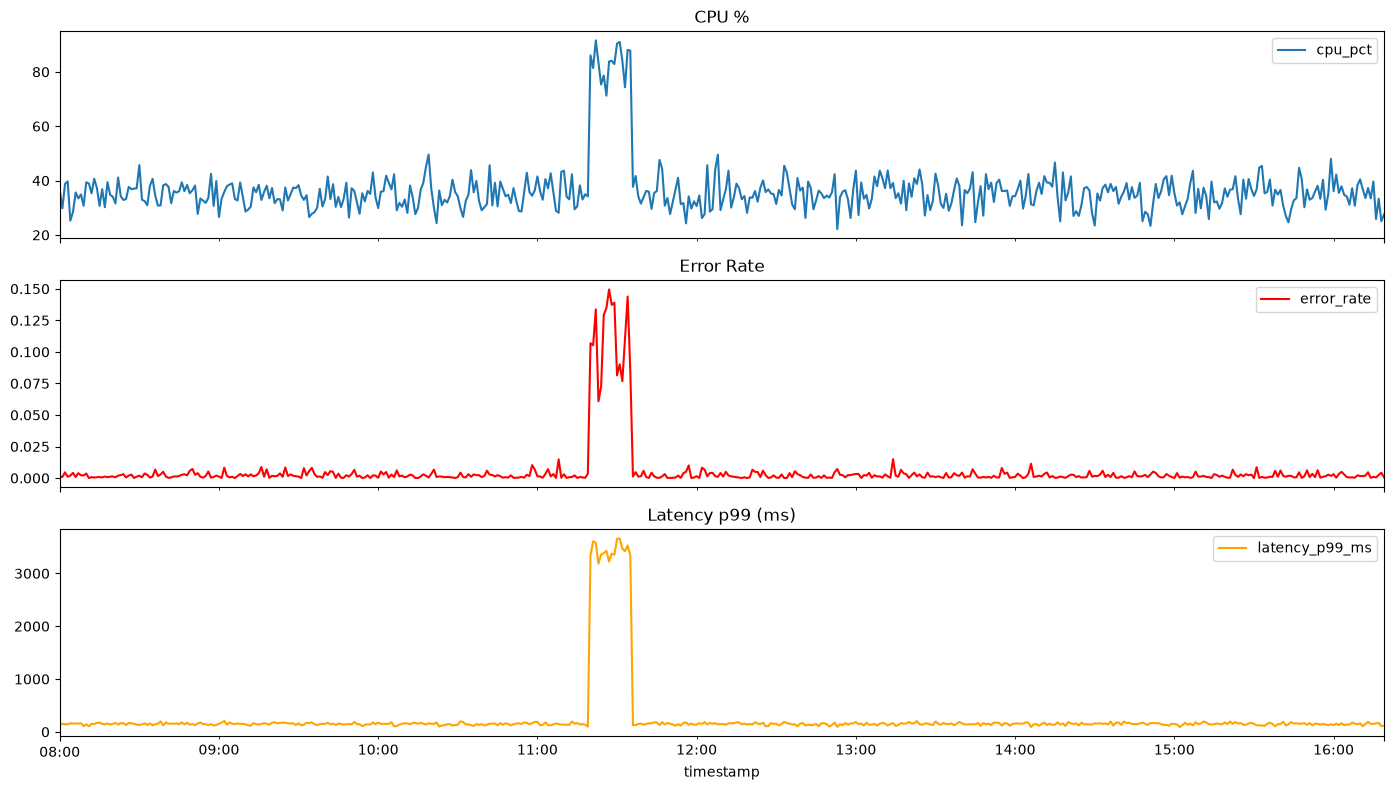

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
df.set_index("timestamp")[["cpu_pct"]].plot(ax=axes[0], title="CPU %")
df.set_index("timestamp")[["error_rate"]].plot(ax=axes[1], title="Error Rate", color="red")
df.set_index("timestamp")[["latency_p99_ms"]].plot(ax=axes[2], title="Latency p99 (ms)", color="orange")
plt.tight_layout()
plt.savefig("metrics_overview.png", dpi=150)
plt.show()

In [17]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
features = df[["cpu_pct", "error_rate", "latency_p99_ms"]]
X = StandardScaler().fit_transform(features) # put all 3 metrics on the same scale
model = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
model.fit(X)
df["is_anomaly"] = (model.predict(X) == -1) # -1 means "flagged as anomaly"
print(f"Anomalies detected: {df['is_anomaly'].sum()} of {len(df)} points")

Anomalies detected: 50 of 500 points


In [18]:
from sklearn.metrics import classification_report

ground_truth = [1 if 200 <= i <= 215 else 0 for i in range(len(df))]
predictions = df["is_anomaly"].astype(int).tolist()

print(classification_report(ground_truth, predictions, target_names=["Normal", "Anomaly"]))

              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96       484
     Anomaly       0.32      1.00      0.48        16

    accuracy                           0.93       500
   macro avg       0.66      0.96      0.72       500
weighted avg       0.98      0.93      0.95       500



In [19]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.9, min_samples=5)
labels = dbscan.fit_predict(X)

df["is_anomaly_dbscan"] = (labels == -1)   # -1 = noise point = anomaly
print(f"Anomalies detected: {df['is_anomaly_dbscan'].sum()} of {len(df)} points")

Anomalies detected: 10 of 500 points


In [20]:
predictions_dbscan = df["is_anomaly_dbscan"].astype(int).tolist()
print(classification_report(ground_truth, predictions_dbscan, target_names=["Normal", "Anomaly"]))

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       484
     Anomaly       1.00      0.62      0.77        16

    accuracy                           0.99       500
   macro avg       0.99      0.81      0.88       500
weighted avg       0.99      0.99      0.99       500



In [22]:
for eps in [0.3, 0.5, 0.7, 0.9, 1.2]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X)
    preds = (labels == -1).astype(int)

    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(
        ground_truth, preds, average="binary", zero_division=0
    )
    flagged = (labels == -1).sum()
    print(f"eps={eps:<4} flagged={flagged:<4} precision={precision:.2f}  recall={recall:.2f}  f1={f1:.2f}")

eps=0.3  flagged=18   precision=0.89  recall=1.00  f1=0.94
eps=0.5  flagged=16   precision=1.00  recall=1.00  f1=1.00
eps=0.7  flagged=11   precision=1.00  recall=0.69  f1=0.81
eps=0.9  flagged=10   precision=1.00  recall=0.62  f1=0.77
eps=1.2  flagged=1    precision=1.00  recall=0.06  f1=0.12


In [24]:
best_eps = 0.5  # replace with whatever the sweep above shows is best

for min_samples in [3, 5, 8, 10]:
    dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)
    preds = (labels == -1).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        ground_truth, preds, average="binary", zero_division=0
    )
    flagged = (labels == -1).sum()
    print(f"min_samples={min_samples:<4} flagged={flagged:<4} precision={precision:.2f}  recall={recall:.2f}  f1={f1:.2f}")

min_samples=3    flagged=16   precision=1.00  recall=1.00  f1=1.00
min_samples=5    flagged=16   precision=1.00  recall=1.00  f1=1.00
min_samples=8    flagged=16   precision=1.00  recall=1.00  f1=1.00
min_samples=10   flagged=16   precision=1.00  recall=1.00  f1=1.00


In [25]:
best_eps = 0.5  # replace with whatever the sweep above shows is best

for min_samples in [3, 5, 8, 10, 15, 20, 100, 200, 300]:
    dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)
    preds = (labels == -1).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        ground_truth, preds, average="binary", zero_division=0
    )
    flagged = (labels == -1).sum()
    print(f"min_samples={min_samples:<4} flagged={flagged:<4} precision={precision:.2f}  recall={recall:.2f}  f1={f1:.2f}")

min_samples=3    flagged=16   precision=1.00  recall=1.00  f1=1.00
min_samples=5    flagged=16   precision=1.00  recall=1.00  f1=1.00
min_samples=8    flagged=16   precision=1.00  recall=1.00  f1=1.00
min_samples=10   flagged=16   precision=1.00  recall=1.00  f1=1.00
min_samples=15   flagged=16   precision=1.00  recall=1.00  f1=1.00
min_samples=20   flagged=16   precision=1.00  recall=1.00  f1=1.00
min_samples=100  flagged=18   precision=0.89  recall=1.00  f1=0.94
min_samples=200  flagged=32   precision=0.50  recall=1.00  f1=0.67
min_samples=300  flagged=84   precision=0.19  recall=1.00  f1=0.32


In [26]:
## PART B Assignment

In [28]:
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import ConsoleSpanExporter, SimpleSpanProcessor
provider = TracerProvider()
provider.add_span_processor(SimpleSpanProcessor(ConsoleSpanExporter()))
trace.set_tracer_provider(provider)
tracer = trace.get_tracer("log-analyzer-agent")

Overriding of current TracerProvider is not allowed


In [30]:
import time

def analyze_logs(log_text: str) -> str:
    with tracer.start_as_current_span("gen_ai.chat") as span:
        span.set_attribute("gen_ai.system", "anthropic")
        span.set_attribute("gen_ai.request.model", "claude-sonnet-5")

        start = time.perf_counter()
        response_text = "no anomalies found" if "ERROR" not in log_text else "possible incident detected"
        latency_ms = (time.perf_counter() - start) * 1000

        span.set_attribute("gen_ai.usage.input_tokens", len(log_text) // 4)
        span.set_attribute("gen_ai.usage.output_tokens", len(response_text) // 4)
        span.set_attribute("gen_ai.response.latency_ms", round(latency_ms, 2))

        return response_text

In [31]:
log_windows = [
    "ERROR db timeout" * 5,
    "ERROR db timeout" * 25,
    "ERROR db timeout" * 75,
    "INFO healthy" * 50,
    "ERROR db timeout" * 150,
]

for window in log_windows:
    result = analyze_logs(window)
    print(f"window size={len(window)} -> {result}")

{
    "name": "gen_ai.chat",
    "context": {
        "trace_id": "0x2fb004ac6da0ed58856f5f792543dfa4",
        "span_id": "0x5898c6c04ff33168",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-08-09T04:14:54.790524Z",
    "end_time": "2026-08-09T04:14:54.790586Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "gen_ai.system": "anthropic",
        "gen_ai.request.model": "claude-sonnet-5",
        "gen_ai.usage.input_tokens": 20,
        "gen_ai.usage.output_tokens": 6,
        "gen_ai.response.latency_ms": 0.0
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.44.0",
            "service.instance.id": "fd4383e1-49a1-4938-8448-0b83431fbed6",
            "service.name": "unknown_service"
        },
        "schema_url

### Part B summary table

| Log window size (chars) | Input tokens | Output tokens | Latency (ms) | Est. cost ($) |
|---|---|---|---|---|
| 80 | 20 | 6 | 0.0 | $0.000100 |
| 400 | 100 | 6 | 0.0 | $0.000260 |
| 1200 | 300 | 6 | 0.0 | $0.000660 |
| 600 | 150 | 4 | 0.0 | $0.000340 |
| 2400 | 600 | 6 | 0.0 | $0.001260 |

Input tokens scale perfectly linearly with window size (exactly chars/4,
the simulator's estimate formula). Output tokens depend only on which of
the two canned responses was picked, not input size — a limitation of
simulating rather than reasoning. Latency reads 0.0ms since the simulated
call has no real work to time.

### Part B reflection questions

**1. Did input tokens scale linearly with window size?**
Yes, exactly. Every one of the 5 windows landed precisely on
`input_tokens = chars / 4` (80→20, 400→100, 1200→300, 600→150, 2400→600) —
a perfect 0.25 ratio across all 5 points. This is expected given the
simulator's estimate formula; a real tokenizer would be close but not
exact, since punctuation and repeated substrings tokenize differently
than plain prose.

**2. Cost at 10 windows/minute, 24/7, for a month?**
Average across the 5 sample windows: 234 input tokens, 5.6 output
tokens per call. At Sonnet 5 pricing ($2/$10 per MTok):
cost per call = (234/1,000,000)×$2 + (5.6/1,000,000)×$10 ≈ $0.000524.
Call volume: 10 × 60 × 24 × 30 = 432,000 calls/month.
Total: 432,000 × $0.000524 ≈ **$226/month**.

**3. What guardrail would prevent runaway cost?**
A per-incident token budget cap, a rate limiter on calls/minute, and a
circuit breaker that falls back to the rule-based simulator if a cost
threshold is hit within a time window. Alert grouping (Assignment,
Section 4) already reduces call volume from "per flagged point" to
"per incident," which is the biggest lever before any of these.

**4. Five metrics for a production dashboard?**
Calls per minute, p50/p99 latency split by span type (tool call vs.
LLM call), token spend rate ($/hour), error rate on tool calls, and
the percentage of RCA reports flagged "low confidence" — a proxy for
when the agent is guessing rather than reasoning from real evidence.